In [3]:
import numpy as np
import pandas as pd


if_matrices = []
tc_matrices = []

for run_number in range(1, 6):

    if_matrix = pd.read_csv(
        f"FOIF_TauMatrix_Run{run_number}.csv",
        index_col=0
    )

    tc_matrix = pd.read_csv(
        f"TracIn_TauMatrix_Run{run_number}.csv",
        index_col=0
    )

    if_matrices.append(if_matrix)
    tc_matrices.append(tc_matrix)

In [5]:
reference_index = if_matrices[0].index
reference_columns = if_matrices[0].columns

for run_number, matrix in enumerate(if_matrices, start=1):
    assert matrix.index.equals(reference_index), (
        f"FOIF row mismatch in run {run_number}"
    )
    assert matrix.columns.equals(reference_columns), (
        f"FOIF column mismatch in run {run_number}"
    )

for run_number, matrix in enumerate(tc_matrices, start=1):
    assert matrix.index.equals(reference_index), (
        f"TracIn row mismatch in run {run_number}"
    )
    assert matrix.columns.equals(reference_columns), (
        f"TracIn column mismatch in run {run_number}"
    )

In [6]:
if_array = np.stack(
    [matrix.to_numpy() for matrix in if_matrices],
    axis=0
)

tc_array = np.stack(
    [matrix.to_numpy() for matrix in tc_matrices],
    axis=0
)

mean_tau_IF = np.mean(if_array, axis=0)
std_tau_IF = np.std(if_array, axis=0, ddof=1)

mean_tau_TC = np.mean(tc_array, axis=0)
std_tau_TC = np.std(tc_array, axis=0, ddof=1)

In [7]:
df_mean_IF = pd.DataFrame(
    mean_tau_IF,
    index=reference_index,
    columns=reference_columns
)

df_std_IF = pd.DataFrame(
    std_tau_IF,
    index=reference_index,
    columns=reference_columns
)

df_mean_TC = pd.DataFrame(
    mean_tau_TC,
    index=reference_index,
    columns=reference_columns
)

df_std_TC = pd.DataFrame(
    std_tau_TC,
    index=reference_index,
    columns=reference_columns
)

In [8]:
tau_matrix_IF = df_mean_IF.to_numpy()
tau_matrix_TC = df_mean_TC.to_numpy()
labels = df_mean_IF.index.tolist()

In [9]:
mask_lower = np.triu(np.ones_like(tau_matrix_IF, dtype=bool), k=1)
triangular_IF = tau_matrix_IF.copy()
triangular_IF[mask_lower] = np.nan
triangular_TC = tau_matrix_TC.copy()
triangular_TC[mask_lower] = np.nan

print(mask_lower)

[[False  True  True  True  True  True  True  True  True  True]
 [False False  True  True  True  True  True  True  True  True]
 [False False False  True  True  True  True  True  True  True]
 [False False False False  True  True  True  True  True  True]
 [False False False False False  True  True  True  True  True]
 [False False False False False False  True  True  True  True]
 [False False False False False False False  True  True  True]
 [False False False False False False False False  True  True]
 [False False False False False False False False False  True]
 [False False False False False False False False False False]]


In [12]:
num_lists = 10

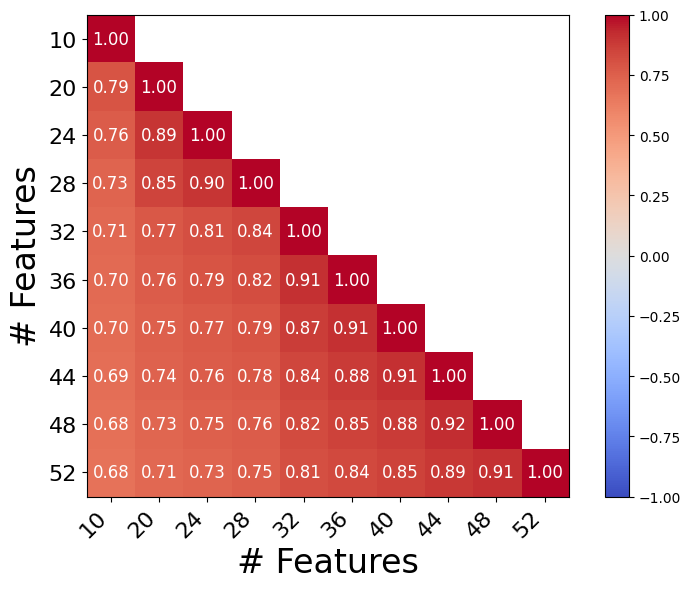

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_IF, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
# ax.set_title("Pairwise Weighted Kendall Tau (IF lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=16)
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels, fontsize=16)

rows, cols = np.where(~np.isnan(triangular_IF))
for i, j in zip(rows, cols):
    val = triangular_IF[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=12, color=txt_color)
plt.xlabel("# Features", fontsize=24)
plt.ylabel("# Features", fontsize=24)
plt.tight_layout()

plt.savefig(
    "Feature_Heatmap_FOIF_mean.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

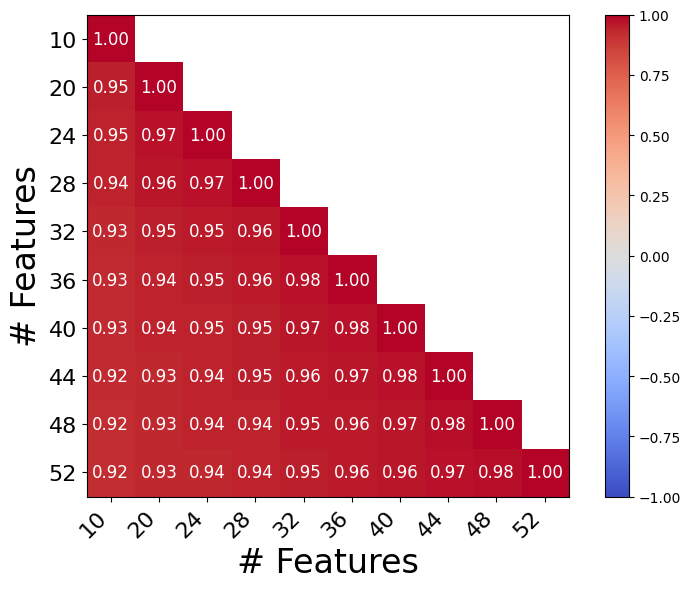

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_TC, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
# ax.set_title("Pairwise Weighted Kendall Tau (TC lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=16)
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels, fontsize=16)

rows, cols = np.where(~np.isnan(triangular_TC))
for i, j in zip(rows, cols):
    val = triangular_TC[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=12, color=txt_color)
plt.xlabel("# Features", fontsize=24)
plt.ylabel("# Features", fontsize=24)
plt.tight_layout()

plt.savefig(
    "Feature_Heatmap_TC_mean.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()